In [4]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn import svm
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

import cv2

import tensorflow as tf
from tensorflow.keras import datasets, models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [5]:
#Importing labels
labels = pd.DataFrame()
labels = pd.read_csv('Labels.csv')

In [6]:
labels.shape

(4750, 1)

In [7]:
labels.head()

,Label
0,Small-flowered Cranesbill
1,Small-flowered Cranesbill
2,Small-flowered Cranesbill
3,Small-flowered Cranesbill
4,Small-flowered Cranesbill


In [8]:
img_array = np.load('images.npy')
img_array

array([[[[ 35,  52,  78],
         [ 36,  49,  76],
         [ 31,  45,  69],
         ...,
         [ 78,  95, 114],
         [ 76,  93, 110],
         [ 80,  95, 109]],

        [[ 33,  46,  68],
         [ 37,  50,  73],
         [ 48,  65,  83],
         ...,
         [ 81,  96, 113],
         [ 74,  89, 105],
         [ 83,  95, 109]],

        [[ 34,  50,  68],
         [ 35,  52,  72],
         [ 70,  85, 101],
         ...,
         [ 83,  97, 112],
         [ 79,  94, 108],
         [ 79,  94, 107]],

        ...,

        [[ 35,  50,  69],
         [ 42,  57,  73],
         [ 42,  57,  72],
         ...,
         [ 60,  76,  92],
         [ 67,  81,  97],
         [ 64,  77,  95]],

        [[ 36,  52,  67],
         [ 48,  63,  78],
         [ 41,  57,  73],
         ...,
         [ 44,  66,  83],
         [ 58,  76,  91],
         [ 57,  74,  90]],

        [[ 44,  58,  70],
         [ 43,  57,  73],
         [ 40,  55,  72],
         ...,
         [ 41,  70,  92],
        

In [9]:
img_array.shape

(4750, 128, 128, 3)

In [10]:
#I want to be able to look at an individual image
#So I convert it to a 3D array
image = img_array[0, :, :, :]
image.shape

(128, 128, 3)

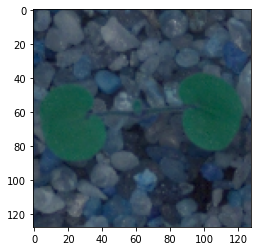

In [82]:
#There we go
plt.imshow(image);

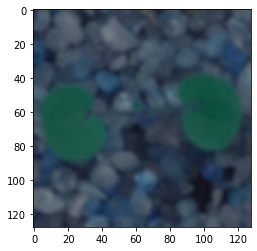

In [83]:
#Gaussian blur
plt.imshow(cv2.GaussianBlur(image, (5, 5), 0));

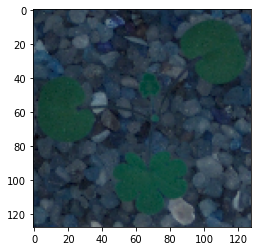

In [52]:
plt.imshow(img_array[1,:,:,:]);

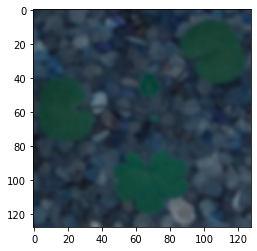

In [71]:
#Gaussian blur
plt.imshow(cv2.GaussianBlur(img_array[1,:,:,:], (5, 5), 0));

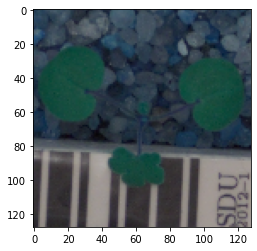

In [51]:
plt.imshow(img_array[55,:,:,:]);

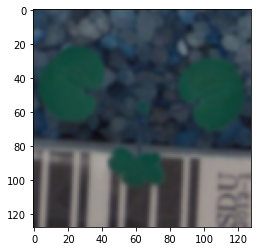

In [72]:
#Gaussian blur
plt.imshow(cv2.GaussianBlur(img_array[55,:,:,:], (5, 5), 0));

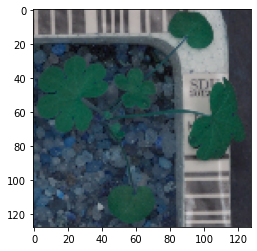

In [50]:
plt.imshow(img_array[223,:,:,:]);

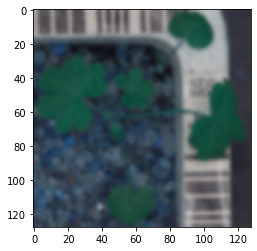

In [73]:
#Gaussian blur
plt.imshow(cv2.GaussianBlur(img_array[223,:,:,:], (5, 5), 0));

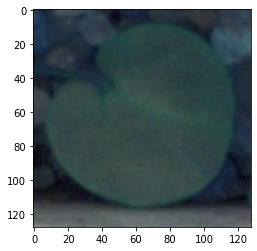

In [49]:
plt.imshow(img_array[300,:,:,:]);

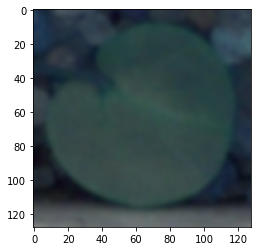

In [74]:
#Gaussian blur
plt.imshow(cv2.GaussianBlur(img_array[300,:,:,:], (5, 5), 0));

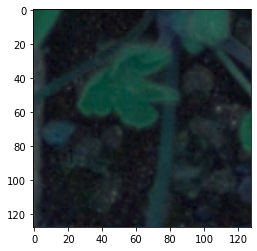

In [48]:
plt.imshow(img_array[120,:,:,:]);

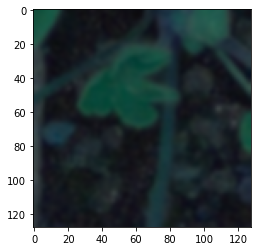

In [75]:
#Gaussian blur
plt.imshow(cv2.GaussianBlur(img_array[120,:,:,:], (5, 5), 0));

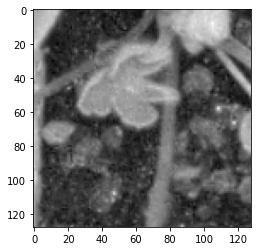

In [78]:
#Grayscale example
gray = cv2.cvtColor(img_array[120,:,:,:], cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray');

In [101]:
#Gaussian Blur--Test

In [102]:
img_list = []

In [103]:
image = img_array[0, :, :, 0]
image.shape

(128, 128)

In [104]:
cv2.GaussianBlur(image, (5, 5), 0)

array([[0.14289217, 0.15450369, 0.18792893, ..., 0.30664828, 0.3068321 ,
        0.30674022],
       [0.14503677, 0.16072306, 0.20130208, ..., 0.30807292, 0.30848652,
        0.30827206],
       [0.14886643, 0.17101717, 0.222932  , ..., 0.30916056, 0.31130517,
        0.31161153],
       ...,
       [0.15257353, 0.15632659, 0.16456802, ..., 0.21614584, 0.23939952,
        0.24745712],
       [0.16265321, 0.16433825, 0.16738665, ..., 0.19097733, 0.21959253,
        0.23079044],
       [0.16611521, 0.16654412, 0.16669731, ..., 0.18039216, 0.21053922,
        0.22303922]], dtype=float32)

In [105]:
img_list.append(1)
img_list

[1]

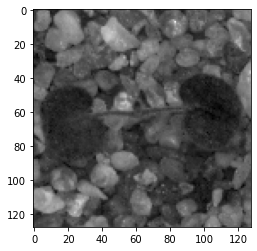

In [100]:
plt.imshow(image, cmap='gray');

In [11]:
#Gaussian Blur
img_list = []

for i in img_array:
    #img = img_array[i, :, :, 0]
    print(i.shape)
    cv2.GaussianBlur(i, (5, 5), 0)
    img_list.append(i)

(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 

(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 

(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 

(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 

(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 

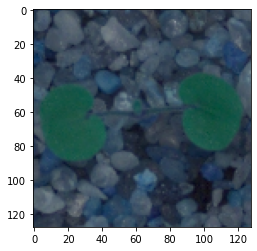

In [21]:
plt.imshow(img_list[0]);

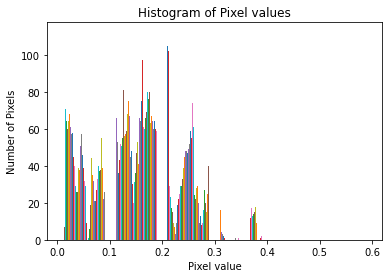

In [81]:
#Visualization of image
plt.hist(gray, bins=6, range=(0.0, 0.6));
plt.xlabel('Pixel value')
plt.ylabel('Number of Pixels')
plt.title('Histogram of Pixel values')
plt.show()

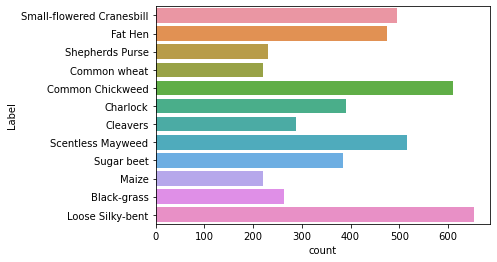

In [59]:
#Visualization of the dataset
sns.countplot(y='Label', data=labels);

In [74]:
#The data isn't very evenly distributed

In [9]:
#Normalization
img_array = img_array.astype('float32') / 255.0

In [10]:
img_array

array([[[[0.13725491, 0.20392157, 0.30588236],
         [0.14117648, 0.19215687, 0.29803923],
         [0.12156863, 0.1764706 , 0.27058825],
         ...,
         [0.30588236, 0.37254903, 0.44705883],
         [0.29803923, 0.3647059 , 0.43137255],
         [0.3137255 , 0.37254903, 0.42745098]],

        [[0.12941177, 0.18039216, 0.26666668],
         [0.14509805, 0.19607843, 0.28627452],
         [0.1882353 , 0.25490198, 0.3254902 ],
         ...,
         [0.31764707, 0.3764706 , 0.44313726],
         [0.2901961 , 0.34901962, 0.4117647 ],
         [0.3254902 , 0.37254903, 0.42745098]],

        [[0.13333334, 0.19607843, 0.26666668],
         [0.13725491, 0.20392157, 0.28235295],
         [0.27450982, 0.33333334, 0.39607844],
         ...,
         [0.3254902 , 0.38039216, 0.4392157 ],
         [0.30980393, 0.36862746, 0.42352942],
         [0.30980393, 0.36862746, 0.41960785]],

        ...,

        [[0.13725491, 0.19607843, 0.27058825],
         [0.16470589, 0.22352941, 0.28627452]

In [12]:
#Train test split
y = labels["Label"]
y = y.values #Convert to numpy array to give to supervised model later

In [13]:
y

array(['Small-flowered Cranesbill', 'Small-flowered Cranesbill',
       'Small-flowered Cranesbill', ..., 'Loose Silky-bent',
       'Loose Silky-bent', 'Loose Silky-bent'], dtype=object)

In [14]:
x = img_array

In [48]:
#x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(x, y, test_size=0.3)
#x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=0.5)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30)

In [49]:
#print(x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(3325, 128, 128, 3) (1425, 128, 128, 3) (3325,) (1425,)


In [50]:
# Convert labels to one hot vectors.
from sklearn.preprocessing import LabelBinarizer
one_Hot = LabelBinarizer()
y_train = one_Hot.fit_transform(y_train)
y_test = one_Hot.fit_transform(y_test)

In [51]:
print(y_train.shape)
print(y_test.shape)

(3325, 12)
(1425, 12)


In [52]:
y_train[0]

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
#Data is already in a compatible shape to bring it into the model.

In [53]:
#CNN model

batch_size = None

model = models.Sequential()
model.add(layers.Conv2D(32, (5, 5), padding='same', activation="relu", input_shape=x_train.shape[1:]))#128
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))
model.add(layers.Conv2D(64, (5, 5), padding='same', activation="relu"))#256
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))
model.add(layers.Conv2D(64, (3, 3), padding='same', activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.4))
model.add(layers.Conv2D(64, (3, 3), padding='same', activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.5))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(256, activation="relu"))#1024
model.add(layers.Dropout(0.5))
model.add(layers.Dense(12, activation="softmax"))

model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_12 (Conv2D)           (None, 128, 128, 32)      2432      
_________________________________________________________________
batch_normalization_12 (Batc (None, 128, 128, 32)      128       
_________________________________________________________________
max_pooling2d_12 (MaxPooling (None, 64, 64, 32)        0         
_________________________________________________________________
dropout_15 (Dropout)         (None, 64, 64, 32)        0         
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 64, 64, 64)        51264     
_________________________________________________________________
batch_normalization_13 (Batc (None, 64, 64, 64)        256       
_________________________________________________________________
max_pooling2d_13 (MaxPooling (None, 32, 32, 64)       

In [54]:
#Adam optimizer
opt = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)

In [55]:
#Train the model using RMSprop
model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

In [56]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', min_delta=0.001, patience=10)

In [57]:
model_checkpoint =  ModelCheckpoint('cifar_cnn_checkpoint_{epoch:02d}_loss{val_loss:.4f}.h5',
                                                           monitor='val_loss',
                                                           verbose=1,
                                                           save_best_only=True,
                                                           save_weights_only=True,
                                                           mode='auto',
                                                           period=1)

In [58]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_12 (Conv2D)           (None, 128, 128, 32)      2432      
_________________________________________________________________
batch_normalization_12 (Batc (None, 128, 128, 32)      128       
_________________________________________________________________
max_pooling2d_12 (MaxPooling (None, 64, 64, 32)        0         
_________________________________________________________________
dropout_15 (Dropout)         (None, 64, 64, 32)        0         
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 64, 64, 64)        51264     
_________________________________________________________________
batch_normalization_13 (Batc (None, 64, 64, 64)        256       
_________________________________________________________________
max_pooling2d_13 (MaxPooling (None, 32, 32, 64)       

In [59]:
x_train = x_train.reshape(x_train.shape[0], 128, 128, 3)
x_test = x_test.reshape(x_test.shape[0], 128, 128, 3)

print(x_train.shape)
print(x_test.shape)

(3325, 128, 128, 3)
(1425, 128, 128, 3)


In [60]:
batch_size = 32
num_classes = 10
epochs = 40
num_predictions = 20

Train on 3325 samples, validate on 1425 samples
Epoch 1/40
3296/3325 [============================>.] - ETA: 0s - loss: 3.5294 - accuracy: 0.1699
Epoch 00001: val_loss improved from inf to 2.50868, saving model to cifar_cnn_checkpoint_01_loss2.5087.h5
3325/3325 [==============================] - 69s 21ms/sample - loss: 3.5140 - accuracy: 0.1732 - val_loss: 2.5087 - val_accuracy: 0.0933
Epoch 2/40
3296/3325 [============================>.] - ETA: 0s - loss: 1.8735 - accuracy: 0.3759
Epoch 00002: val_loss did not improve from 2.50868
3325/3325 [==============================] - 70s 21ms/sample - loss: 1.8714 - accuracy: 0.3762 - val_loss: 2.6320 - val_accuracy: 0.0933
Epoch 3/40
3296/3325 [============================>.] - ETA: 0s - loss: 1.5252 - accuracy: 0.4797
Epoch 00003: val_loss did not improve from 2.50868
3325/3325 [==============================] - 69s 21ms/sample - loss: 1.5236 - accuracy: 0.4797 - val_loss: 3.0468 - val_accuracy: 0.0933
Epoch 4/40
3296/3325 [=================

Epoch 28/40
3296/3325 [============================>.] - ETA: 0s - loss: 0.5609 - accuracy: 0.8083
Epoch 00028: val_loss did not improve from 0.63761
3325/3325 [==============================] - 70s 21ms/sample - loss: 0.5593 - accuracy: 0.8087 - val_loss: 1.1328 - val_accuracy: 0.6056
Epoch 29/40
3296/3325 [============================>.] - ETA: 0s - loss: 0.5242 - accuracy: 0.8204
Epoch 00029: val_loss did not improve from 0.63761
3325/3325 [==============================] - 70s 21ms/sample - loss: 0.5249 - accuracy: 0.8205 - val_loss: 0.9610 - val_accuracy: 0.6344
Epoch 30/40
3296/3325 [============================>.] - ETA: 0s - loss: 0.5031 - accuracy: 0.8246
Epoch 00030: val_loss did not improve from 0.63761
3325/3325 [==============================] - 71s 21ms/sample - loss: 0.5020 - accuracy: 0.8253 - val_loss: 2.3654 - val_accuracy: 0.3789
Epoch 31/40
3296/3325 [============================>.] - ETA: 0s - loss: 0.4932 - accuracy: 0.8225
Epoch 00031: val_loss did not improve fr

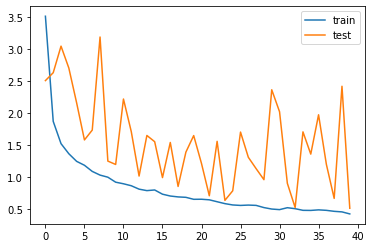

In [61]:
history = model.fit(x_train,
                    y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    shuffle=True,
                    verbose=1,
                    callbacks=[early_stopping,model_checkpoint])

#Training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [62]:
# Score trained model.
scores = model.evaluate(x_test, y_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])


1425/1 [===============================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

Test loss: 0.5145523046610648
Test accuracy: 0.83859646
